---
tags: [algorithm, machine-learning]
---
# Quantum Kernel Classification

This tutorial demonstrates **quantum kernel methods** for binary
classification using Qamomile. The idea is to use a parameterized quantum
circuit to compute a kernel (similarity) matrix, which is then fed to a
classical Support Vector Machine (SVM).

We will:

1. Prepare a toy dataset (`make_circles`) that is not linearly separable.
2. Build a **feature map** circuit $U(x)$ as a `@qkernel`.
3. Construct the **overlap kernel** $k(x, x') = |\langle 0^n | U(x')^\dagger U(x) | 0^n \rangle|^2$.
4. Compute the Gram matrix and train an SVM with `kernel="precomputed"`.
5. Compare against classical linear and RBF kernels.

## Background: Quantum Kernel Methods

A quantum kernel estimates the similarity between two data points by
measuring the overlap of their quantum feature states:

$$
k(x, x') = |\langle 0^n | U(x')^\dagger \, U(x) | 0^n \rangle|^2
$$

This overlap is estimated by running $U(x')^\dagger U(x)$ on $|0^n\rangle$
and measuring the probability of obtaining the all-zero bitstring.
The resulting kernel matrix can be plugged into any kernel-based
classifier such as an SVM.

In [1]:
# !pip install "qamomile[qiskit,visualization]" scikit-learn

## Hyperparameters

In [2]:
import math
import os

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

RANDOM_STATE = 7
N_SAMPLES = 8 if docs_test_mode else 40
TEST_SIZE = 0.25

LAYERS = 2       # number of feature-map repetitions (bound at transpile time)
SHOTS = 64 if docs_test_mode else 1024
C_SVC = 1.0

## Dataset

We use scikit-learn's `make_circles` to generate a 2D dataset with two
concentric circles — a classic example where a linear classifier fails.

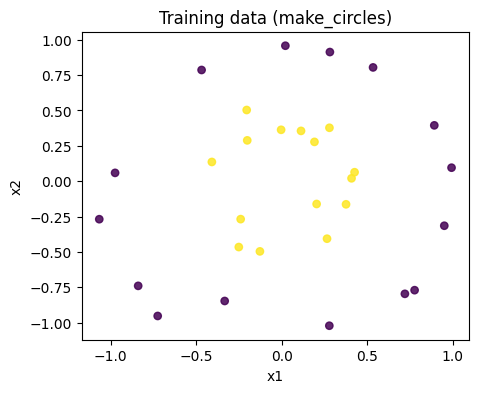

In [3]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

X_raw, y = make_circles(
    n_samples=N_SAMPLES,
    noise=0.08,
    factor=0.40,
    random_state=RANDOM_STATE,
)
assert X_raw.shape == (N_SAMPLES, 2)
assert y.shape == (N_SAMPLES,)
assert set(y.tolist()) == {0, 1}

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
# train + test partition recovers the whole dataset; stratify preserves
# the binary label set.
assert len(X_train_raw) + len(X_test_raw) == N_SAMPLES
assert X_train_raw.shape[1] == 2 and X_test_raw.shape[1] == 2
assert set(y_train.tolist()) == {0, 1}
assert set(y_test.tolist()) == {0, 1}

plt.figure(figsize=(5, 4))
plt.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.85,
)
plt.title("Training data (make_circles)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## Classical Preprocessing (Feature Lifting)

Before encoding data into the quantum circuit, we apply a classical **feature lifting** step that maps the original 2D input into a higher-dimensional space. By adding nonlinear combinations of the raw features, we give the quantum feature map richer structure to work with.

The two-stage pipeline is:

1. Scale the raw 2D coordinates into $[0, \pi]$.
2. Construct nonlinear features $(x_0 - x_1)^2$ and $(x_0 + x_1)^2$
   and scale those into $[0, \pi]$ as well.

This yields a 4-dimensional feature vector per sample:
$f(x) = [x_0, x_1, (x_0 - x_1)^2, (x_0 + x_1)^2]$.

The quantum kernel is therefore defined on the preprocessed features:

$$
k(x, x') = |\langle 0^n | U(f(x'))^\dagger \, U(f(x)) | 0^n \rangle|^2
$$

In [4]:
from sklearn.preprocessing import MinMaxScaler

angle_scaler = MinMaxScaler(feature_range=(0.0, math.pi), clip=True)
pair_scaler = MinMaxScaler(feature_range=(0.0, math.pi), clip=True)

X_train_ang = angle_scaler.fit_transform(X_train_raw)
X_test_ang = angle_scaler.transform(X_test_raw)


def lift_features(X_ang: np.ndarray) -> np.ndarray:
    x0 = X_ang[:, 0]
    x1 = X_ang[:, 1]
    xdiff = (x0 - x1) ** 2
    xsum = (x0 + x1) ** 2
    return np.column_stack([x0, x1, xdiff, xsum])


F_train = lift_features(X_train_ang)
F_test = lift_features(X_test_ang)

# scale only the nonlinear pair features
F_train[:, 2:4] = pair_scaler.fit_transform(F_train[:, 2:4])
F_test[:, 2:4] = pair_scaler.transform(F_test[:, 2:4])
# Feature lifting widens (n, 2) -> (n, 4); MinMaxScaler clip=True keeps
# every entry inside [0, pi].
assert F_train.shape == (len(X_train_raw), 4)
assert F_test.shape == (len(X_test_raw), 4)
assert F_train.min() >= 0.0 and F_train.max() <= math.pi + 1e-12
assert F_test.min() >= 0.0 and F_test.max() <= math.pi + 1e-12

## Feature Map Circuit

The feature block $U(x)$ encodes data via single-qubit rotations and
entangling gates. We also implement its exact inverse $U(x)^\dagger$
manually by reversing the gate order and negating all angles.

In [5]:
import qamomile.circuit as qmc


@qmc.qkernel
def feature_block(
    q0: qmc.Qubit,
    q1: qmc.Qubit,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
) -> tuple[qmc.Qubit, qmc.Qubit]:
    # Local basis mixing
    q0 = qmc.h(q0)
    q1 = qmc.h(q1)

    # Local data encoding
    q0 = qmc.rz(q0, x0)
    q1 = qmc.rz(q1, x1)
    q0 = qmc.ry(q0, x0)
    q1 = qmc.ry(q1, x1)

    # Entangling/data-dependent phase
    q0, q1 = qmc.cz(q0, q1)
    q0, q1 = qmc.rzz(q0, q1, xdiff)

    # Additional nonlinear phase
    q0 = qmc.rz(q0, xsum)
    q1 = qmc.rz(q1, xsum)

    return q0, q1


@qmc.qkernel
def feature_block_dagger(
    q0: qmc.Qubit,
    q1: qmc.Qubit,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
) -> tuple[qmc.Qubit, qmc.Qubit]:
    # Reverse order, negated angles (0.0 - x because Float has no unary minus)
    q1 = qmc.rz(q1, 0.0 - xsum)
    q0 = qmc.rz(q0, 0.0 - xsum)

    q0, q1 = qmc.rzz(q0, q1, 0.0 - xdiff)
    q0, q1 = qmc.cz(q0, q1)

    q1 = qmc.ry(q1, 0.0 - x1)
    q0 = qmc.ry(q0, 0.0 - x0)
    q1 = qmc.rz(q1, 0.0 - x1)
    q0 = qmc.rz(q0, 0.0 - x0)

    q1 = qmc.h(q1)
    q0 = qmc.h(q0)

    return q0, q1

## Overlap Kernel Circuit

The full kernel circuit applies $U(x)$ followed by $U(x')^\dagger$.
The kernel value $k(x, x')$ is the probability of measuring $|00\rangle$.

We repeat the feature block `layers` times for increased expressiveness.
Since `layers` is a structure parameter, it is bound at transpile time.

In [6]:
@qmc.qkernel
def overlap_kernel(
    layers: qmc.UInt,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
    xp0: qmc.Float,
    xp1: qmc.Float,
    xpdiff: qmc.Float,
    xpsum: qmc.Float,
) -> tuple[qmc.Bit, qmc.Bit]:
    q0 = qmc.qubit(name="q0")
    q1 = qmc.qubit(name="q1")

    for _ in qmc.range(layers):
        q0, q1 = feature_block(q0, q1, x0, x1, xdiff, xsum)

    for _ in qmc.range(layers):
        q0, q1 = feature_block_dagger(q0, q1, xp0, xp1, xpdiff, xpsum)

    return qmc.measure(q0), qmc.measure(q1)

## Inspect the Circuit

We can visualize the circuit by providing concrete values and use
`estimate_resources` to see the gate counts.

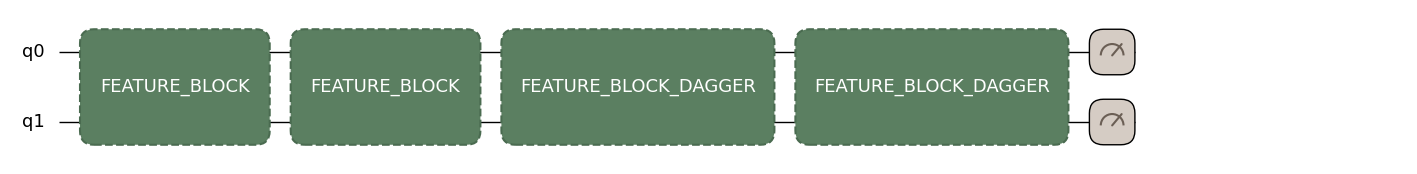

In [7]:
overlap_kernel.draw(
    layers=LAYERS,
    x0=0.4, x1=1.1, xdiff=0.8, xsum=1.6,
    xp0=0.9, xp1=0.7, xpdiff=0.2, xpsum=1.2,
    fold_loops=False,
)

In [8]:
est = overlap_kernel.estimate_resources()
print("=== symbolic resource estimate ===")
print("qubits:", est.qubits)
print("total gates:", est.gates.total)
# The overlap circuit always acts on exactly 2 qubits, regardless of layers.
assert est.qubits == 2

=== symbolic resource estimate ===
qubits: 2
total gates: 20*layers


## Transpile Once, Bind Many Times

We bind the structural parameter `layers` at transpile time, while
keeping the data features (`x0`, `x1`, ..., `xpsum`) as runtime
parameters. This lets us reuse the same compiled circuit for every
pair of data points.

In [9]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

exe = transpiler.transpile(
    overlap_kernel,
    bindings={"layers": LAYERS},
    parameters=[
        "x0", "x1", "xdiff", "xsum",
        "xp0", "xp1", "xpdiff", "xpsum",
    ],
)

executor = transpiler.executor()

## Kernel Evaluation Utilities

We define helper functions to:
- Extract the $|00\rangle$ probability from a sample result.
- Compute a single kernel value $k(f, f')$.
- Build the symmetric training kernel matrix.
- Build the rectangular test kernel matrix.
- Project a noisy kernel matrix to a valid PSD (positive semi-definite)
  correlation matrix (needed because shot noise can produce slightly
  non-PSD matrices).

In [10]:
def zero_probability(sample_result) -> float:
    total = 0
    zero_zero = 0

    for outcome, count in sample_result.results:
        total += count
        if outcome == (0, 0):
            zero_zero += count

    if total == 0:
        return 0.0
    return zero_zero / total


def kernel_value(f: np.ndarray, fp: np.ndarray, shots: int = SHOTS) -> float:
    result = exe.sample(
        executor,
        shots=shots,
        bindings={
            "x0": float(f[0]),
            "x1": float(f[1]),
            "xdiff": float(f[2]),
            "xsum": float(f[3]),
            "xp0": float(fp[0]),
            "xp1": float(fp[1]),
            "xpdiff": float(fp[2]),
            "xpsum": float(fp[3]),
        },
    ).result()

    return zero_probability(result)


def train_kernel_matrix(F: np.ndarray, shots: int = SHOTS) -> np.ndarray:
    n = len(F)
    K = np.empty((n, n), dtype=float)

    for i in range(n):
        K[i, i] = 1.0
        for j in range(i + 1, n):
            val = kernel_value(F[i], F[j], shots=shots)
            K[i, j] = val
            K[j, i] = val

    return K


def cross_kernel_matrix(
    F_left: np.ndarray, F_right: np.ndarray, shots: int = SHOTS
) -> np.ndarray:
    K = np.empty((len(F_left), len(F_right)), dtype=float)

    for i, f in enumerate(F_left):
        for j, fp in enumerate(F_right):
            K[i, j] = kernel_value(f, fp, shots=shots)

    return K


def project_to_psd_correlation(K: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    K = 0.5 * (K + K.T)

    eigvals, eigvecs = np.linalg.eigh(K)
    eigvals = np.maximum(eigvals, eps)
    K_psd = (eigvecs * eigvals) @ eigvecs.T

    d = np.sqrt(np.maximum(np.diag(K_psd), eps))
    K_psd = K_psd / np.outer(d, d)

    K_psd = 0.5 * (K_psd + K_psd.T)
    np.fill_diagonal(K_psd, 1.0)

    return K_psd

## Compute Gram Matrices

We compute the training kernel matrix (symmetric, $n \times n$) and the
test kernel matrix (rectangular, $m \times n$).

> **Note:** This step is computationally expensive because we evaluate
> $O(n^2)$ quantum circuits. For large datasets, consider subsampling
> or using approximate methods.

In [11]:
K_train = train_kernel_matrix(F_train, shots=SHOTS)
K_train = project_to_psd_correlation(K_train)
# After PSD correlation projection the train Gram matrix is symmetric
# with unit diagonal and is positive semi-definite (no negative
# eigenvalues beyond the eps floor used inside the projector).
assert K_train.shape == (len(F_train), len(F_train))
assert np.allclose(K_train, K_train.T)
assert np.allclose(np.diag(K_train), 1.0)
assert float(np.linalg.eigvalsh(K_train).min()) >= -1e-9

K_test = cross_kernel_matrix(F_test, F_train, shots=SHOTS)
# Probabilities estimated from shot counts are always in [0, 1].
assert K_test.shape == (len(F_test), len(F_train))
assert K_test.min() >= 0.0 and K_test.max() <= 1.0

## Train Classifiers

We train three SVMs for comparison:
- **Quantum kernel SVC** using the precomputed quantum kernel matrix.
- **Linear SVC** using the raw 2D features (expected to fail on circles).
- **RBF SVC** using a classical Gaussian kernel (strong baseline).

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

qsvc = SVC(kernel="precomputed", C=C_SVC)
qsvc.fit(K_train, y_train)
y_pred_qk = qsvc.predict(K_test)

linear_svc = SVC(kernel="linear", C=C_SVC)
linear_svc.fit(X_train_raw, y_train)
y_pred_linear = linear_svc.predict(X_test_raw)

rbf_svc = SVC(kernel="rbf", C=C_SVC, gamma="scale")
rbf_svc.fit(X_train_raw, y_train)
y_pred_rbf = rbf_svc.predict(X_test_raw)

print("=== test accuracy ===")
print("Quantum kernel SVC :", accuracy_score(y_test, y_pred_qk))
print("Linear SVC         :", accuracy_score(y_test, y_pred_linear))
print("RBF SVC            :", accuracy_score(y_test, y_pred_rbf))
# Every classifier produces exactly one prediction per test point and
# only emits labels drawn from the training label set.
assert y_pred_qk.shape == y_test.shape
assert y_pred_linear.shape == y_test.shape
assert y_pred_rbf.shape == y_test.shape
assert set(y_pred_qk.tolist()).issubset({0, 1})
assert set(y_pred_linear.tolist()).issubset({0, 1})
assert set(y_pred_rbf.tolist()).issubset({0, 1})

=== test accuracy ===
Quantum kernel SVC : 0.9
Linear SVC         : 0.5
RBF SVC            : 1.0


## Visualization

We plot four panels:
1. The training data.
2. The quantum kernel matrix (Gram matrix).
3. The quantum kernel SVC decision boundary.
4. The classical RBF SVC decision boundary for comparison.

### Decision Boundary Helpers

In [13]:
GRID_SIZE = 3 if docs_test_mode else 15


def preprocess_for_kernel(X_raw_points: np.ndarray) -> np.ndarray:
    X_ang = angle_scaler.transform(X_raw_points)
    F = lift_features(X_ang)
    F[:, 2:4] = pair_scaler.transform(F[:, 2:4])
    return F


def quantum_decision_grid(
    clf: SVC,
    X_train_features: np.ndarray,
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    grid_size: int = GRID_SIZE,
    shots: int = SHOTS,
):
    xs = np.linspace(x_min, x_max, grid_size)
    ys = np.linspace(y_min, y_max, grid_size)
    xx, yy = np.meshgrid(xs, ys)

    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    F_grid = preprocess_for_kernel(grid_points)

    K_grid = cross_kernel_matrix(F_grid, X_train_features, shots=shots)

    zz = clf.predict(K_grid).reshape(xx.shape)
    return xx, yy, zz

### Plot Results

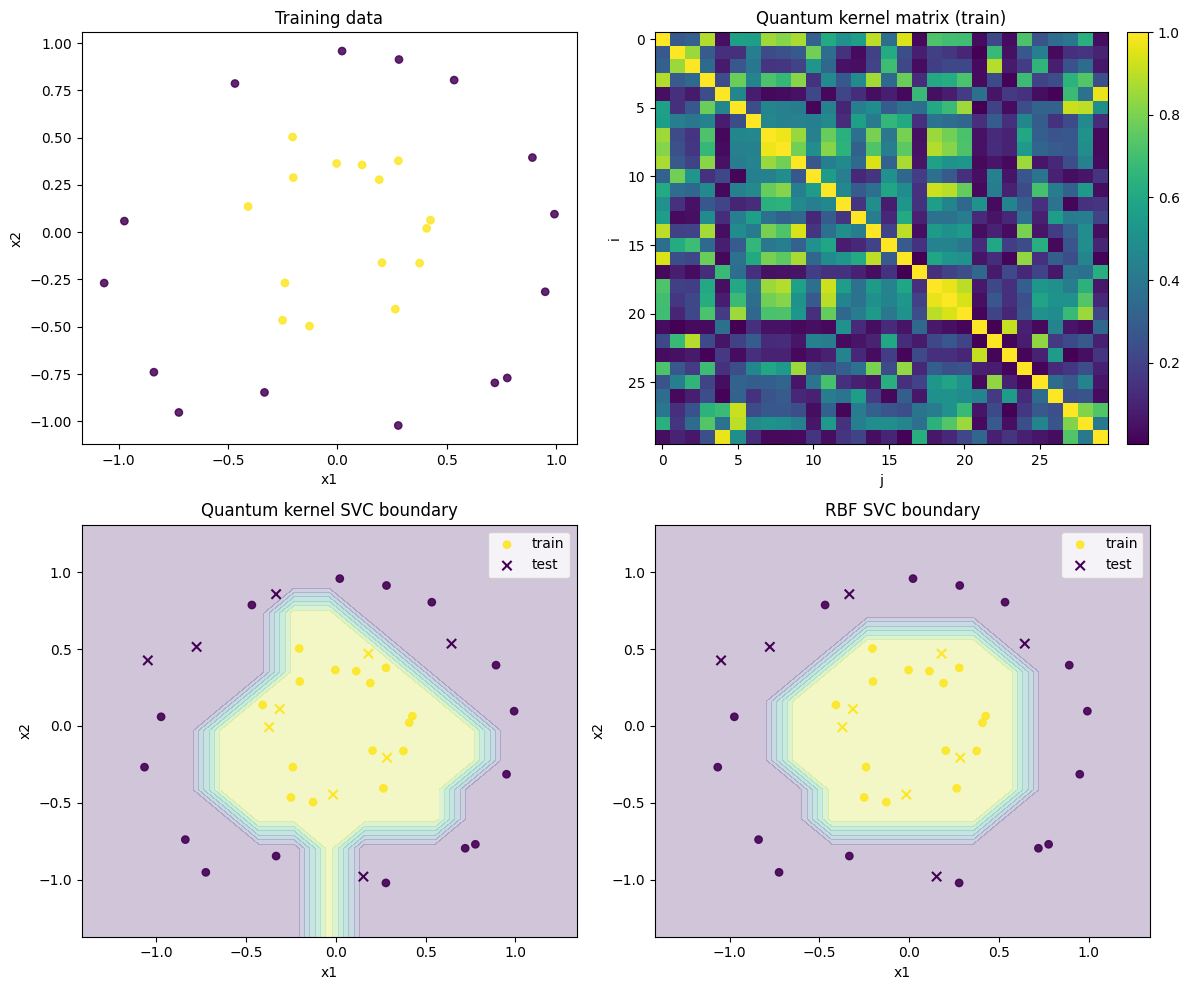

In [14]:
margin = 0.35
x_min = X_raw[:, 0].min() - margin
x_max = X_raw[:, 0].max() + margin
y_min = X_raw[:, 1].min() - margin
y_max = X_raw[:, 1].max() + margin

xx_qk, yy_qk, zz_qk = quantum_decision_grid(
    qsvc, F_train, x_min, x_max, y_min, y_max,
    grid_size=GRID_SIZE, shots=SHOTS,
)

xx_cl, yy_cl = np.meshgrid(
    np.linspace(x_min, x_max, GRID_SIZE),
    np.linspace(y_min, y_max, GRID_SIZE),
)
grid_raw = np.column_stack([xx_cl.ravel(), yy_cl.ravel()])
zz_lin = linear_svc.predict(grid_raw).reshape(xx_cl.shape)
zz_rbf = rbf_svc.predict(grid_raw).reshape(xx_cl.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) raw dataset
ax = axes[0, 0]
ax.scatter(X_train_raw[:, 0], X_train_raw[:, 1], c=y_train, s=28, alpha=0.85)
ax.set_title("Training data")
ax.set_xlabel("x1")
ax.set_ylabel("x2")

# (b) train kernel matrix
ax = axes[0, 1]
im = ax.imshow(K_train, aspect="auto")
ax.set_title("Quantum kernel matrix (train)")
ax.set_xlabel("j")
ax.set_ylabel("i")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (c) quantum kernel decision boundary
ax = axes[1, 0]
ax.contourf(xx_qk, yy_qk, zz_qk, alpha=0.25)
ax.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.9, label="train",
)
ax.scatter(
    X_test_raw[:, 0], X_test_raw[:, 1],
    c=y_test, s=45, marker="x", label="test",
)
ax.set_title("Quantum kernel SVC boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

# (d) RBF baseline
ax = axes[1, 1]
ax.contourf(xx_cl, yy_cl, zz_rbf, alpha=0.25)
ax.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.9, label="train",
)
ax.scatter(
    X_test_raw[:, 0], X_test_raw[:, 1],
    c=y_test, s=45, marker="x", label="test",
)
ax.set_title("RBF SVC boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

plt.tight_layout()
plt.show()

## Interpreting the Results

The visualization above shows how well the quantum kernel classifier captures the nonlinear class structure of `make_circles`.

The **upper-left panel** (training data) shows that the two classes have a concentric-circle structure that cannot be separated by a straight line.
In fact, the linear SVC achieved a test accuracy of 0.5 in this run, which is close to random guessing.
This is because a linear decision boundary in the raw 2D coordinates cannot represent the concentric-circle class structure.

The **upper-right panel** (quantum kernel matrix) displays the Gram matrix of pairwise similarities

$$
k(x, x') =
\left|
\langle 0^n |
U(f(x'))^\dagger U(f(x))
|0^n\rangle
\right|^2
$$

computed over the training set.
Diagonal entries are always 1 (each point is identical to itself).
Off-diagonal entries indicate how close two data points are in the quantum feature space.
Since the matrix rows are not sorted by class label, we cannot read a clear block structure directly.
Nevertheless, when this matrix is passed to the SVM, it enables classification of data that is not linearly separable in the original 2D space.

The **lower-left panel** (quantum kernel SVC boundary) shows a nonlinear decision boundary in input space.
In this run, the quantum kernel SVC achieved a test accuracy of 1.0.
This indicates that, for this small `make_circles` dataset, the quantum feature map we designed provides an effective similarity measure.

The **lower-right panel** (RBF SVC) also forms a nonlinear decision boundary.
In this run, the RBF SVC likewise achieved a test accuracy of 1.0.
Thus, on this dataset both the quantum kernel SVC and the RBF SVC correctly classified all test points.
However, the RBF SVC boundary is relatively smooth, whereas the quantum kernel SVC boundary appears somewhat rougher.
This may be due to the small visualization grid (`GRID_SIZE = 15`) and the estimation of kernel values from `SHOTS = 1024` samples.

In summary, the results of this experiment are:

- Linear SVC: 0.5
- Quantum kernel SVC: 1.0
- RBF SVC: 1.0

The quantum kernel SVC clearly outperformed the linear SVC and matched the test accuracy of the RBF SVC.

However, this result alone does not demonstrate quantum advantage.
The dataset is small-scale for visualization purposes, and classical feature lifting is also applied.
What this notebook demonstrates is:
"We can construct a quantum kernel matrix with Qamomile and feed it to an SVM for nonlinear binary classification."
Discussing whether a quantum kernel is inherently superior to classical kernels would require larger datasets, multiple random seeds, shot-count dependence, layer-depth dependence, and detailed comparisons with classical kernels.

Also note that the quantum kernel evaluation executes a quantum circuit for each pair of data points.
For a training set of size $n$, computing the training kernel matrix requires roughly $O(n^2)$ kernel evaluations.
This is not an issue for small datasets like ours, but the computational cost grows rapidly as the dataset size increases.